# Actividad 5.9 - k-Means con PCA

En esta práctica se realiza:

1. Clustering con **k-Means** usando los **3 atributos** del dataset `tetra.arff`.
2. Reducción de dimensionalidad con **PCA a 2 componentes**.
3. Nuevo clustering con **k-Means** sobre las **2 componentes principales**.
4. Comparación de métricas internas de clustering entre ambos enfoques.

Dataset utilizado: `tetra.arff` cargado desde la URL oficial del repositorio de benchmarking.

In [2]:
import io
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from scipy.io import arff
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)

TETRA_URL = "https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/tetra.arff"


def load_tetra_dataset_from_url(url: str):
    """Carga tetra.arff desde una URL remota (sin usar datos sintéticos)."""
    try:
        with urllib.request.urlopen(url, timeout=30) as response:
            content = response.read().decode("utf-8", errors="replace")
    except Exception as exc:
        raise RuntimeError(
            f"No se pudo descargar el dataset desde {url}. Revisa la conexión o la URL."
        ) from exc

    raw, _ = arff.loadarff(io.StringIO(content))
    df = pd.DataFrame(raw)

    # Convierte columnas tipo bytes a str
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) < 3:
        raise ValueError("El dataset necesita al menos 3 atributos numéricos para la práctica.")

    feature_cols = numeric_cols[:3]
    X = df[feature_cols].to_numpy()

    non_numeric_cols = [c for c in df.columns if c not in numeric_cols]
    if non_numeric_cols:
        k = df[non_numeric_cols[0]].nunique()
    else:
        k = 4

    source = f"Dataset cargado desde URL: {url}"
    return X, feature_cols, int(k), source


X3, feature_names, k, data_source = load_tetra_dataset_from_url(TETRA_URL)
print(data_source)
print(f"Forma de X (3 atributos): {X3.shape}")
print(f"Atributos usados: {feature_names}")
print(f"Número de clusters (k): {k}")

Dataset cargado desde URL: https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/tetra.arff
Forma de X (3 atributos): (400, 3)
Atributos usados: ['x', 'y', 'z']
Número de clusters (k): 4


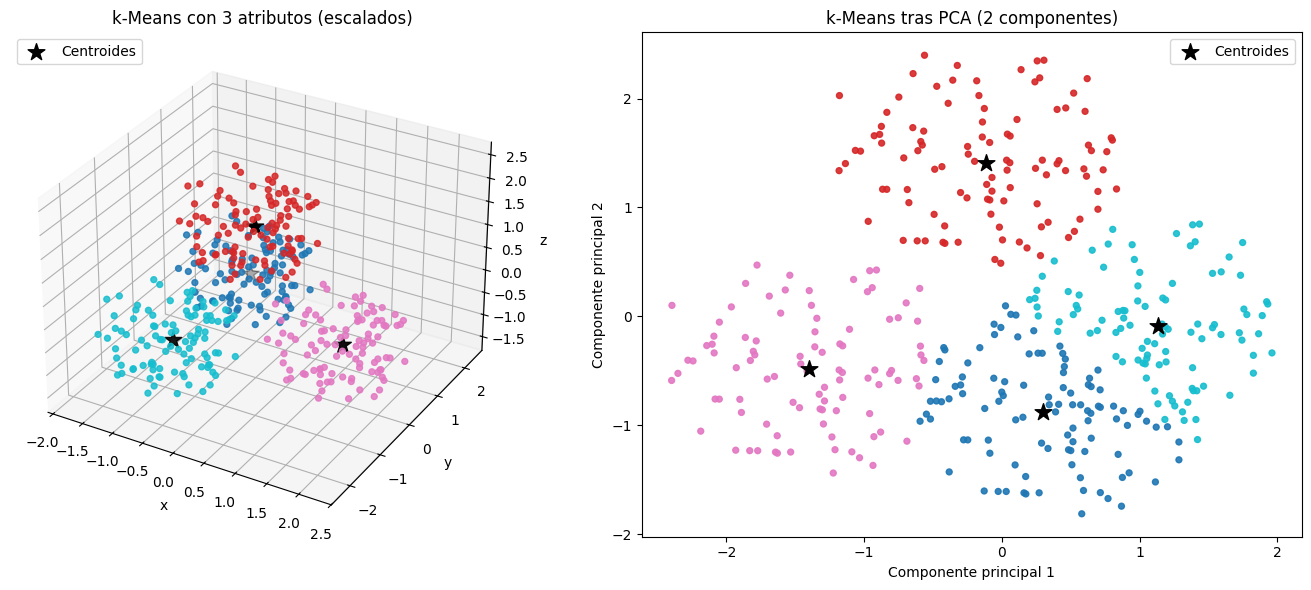

Varianza explicada por PCA (PC1 + PC2): 0.6768


In [3]:
# Estandarización para evitar sesgos por escala
scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

# k-Means en 3D (atributos originales)
kmeans_3d = KMeans(n_clusters=k, random_state=42, n_init=20)
labels_3d = kmeans_3d.fit_predict(X3_scaled)
centers_3d = kmeans_3d.cluster_centers_

# PCA a 2D
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X3_scaled)

# k-Means en 2D (componentes principales)
kmeans_2d = KMeans(n_clusters=k, random_state=42, n_init=20)
labels_2d = kmeans_2d.fit_predict(X2)
centers_2d = kmeans_2d.cluster_centers_

# Visualización comparada
fig = plt.figure(figsize=(14, 6))

# Gráfico 3D
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
scatter1 = ax1.scatter(
    X3_scaled[:, 0], X3_scaled[:, 1], X3_scaled[:, 2],
    c=labels_3d, cmap="tab10", s=18, alpha=0.85
)
ax1.scatter(
    centers_3d[:, 0], centers_3d[:, 1], centers_3d[:, 2],
    c="black", marker="*", s=160, label="Centroides"
)
ax1.set_title("k-Means con 3 atributos (escalados)")
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_zlabel(feature_names[2])
ax1.legend(loc="upper left")

# Gráfico 2D (PCA)
ax2 = fig.add_subplot(1, 2, 2)
scatter2 = ax2.scatter(
    X2[:, 0], X2[:, 1],
    c=labels_2d, cmap="tab10", s=18, alpha=0.9
)
ax2.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    c="black", marker="*", s=160, label="Centroides"
)
ax2.set_title("k-Means tras PCA (2 componentes)")
ax2.set_xlabel("Componente principal 1")
ax2.set_ylabel("Componente principal 2")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"Varianza explicada por PCA (PC1 + PC2): {pca.explained_variance_ratio_.sum():.4f}")

In [4]:
def clustering_metrics(X, labels, model):
    return {
        "inercia (menor mejor)": model.inertia_,
        "silhouette (mayor mejor)": silhouette_score(X, labels),
        "calinski-harabasz (mayor mejor)": calinski_harabasz_score(X, labels),
        "davies-bouldin (menor mejor)": davies_bouldin_score(X, labels),
    }


metrics_3d = clustering_metrics(X3_scaled, labels_3d, kmeans_3d)
metrics_2d = clustering_metrics(X2, labels_2d, kmeans_2d)

comparison = pd.DataFrame([
    {"espacio": "3 atributos", **metrics_3d},
    {"espacio": "PCA (2 componentes)", **metrics_2d},
])

comparison

,espacio,inercia (menor mejor),silhouette (mayor mejor),calinski-harabasz (mayor mejor),davies-bouldin (menor mejor)
0,3 atributos,287.762863,0.505794,418.453239,0.663952
1,PCA (2 componentes),181.716285,0.415718,457.963042,0.846968


In [5]:
# Comentario automático de resultados
s3 = metrics_3d["silhouette (mayor mejor)"]
s2 = metrics_2d["silhouette (mayor mejor)"]
ch3 = metrics_3d["calinski-harabasz (mayor mejor)"]
ch2 = metrics_2d["calinski-harabasz (mayor mejor)"]
db3 = metrics_3d["davies-bouldin (menor mejor)"]
db2 = metrics_2d["davies-bouldin (menor mejor)"]

print("Conclusión:")
print(f"- Silhouette: 3D={s3:.4f} | PCA-2D={s2:.4f}")
print(f"- Calinski-Harabasz: 3D={ch3:.2f} | PCA-2D={ch2:.2f}")
print(f"- Davies-Bouldin: 3D={db3:.4f} | PCA-2D={db2:.4f}")

if (s2 >= s3 * 0.95) and (db2 <= db3 * 1.10):
    print(
        "\nInterpretación: PCA conserva bastante bien la estructura de clusters. "
        "Con 2 dimensiones se simplifica la visualización sin perder demasiada calidad."
    )
else:
    print(
        "\nInterpretación: al reducir a 2D con PCA se pierde parte de la separación natural "
        "de los clusters. Aun así, la proyección facilita la interpretación visual."
    )

print(
    "\nNota: es normal que las métricas cambien tras PCA, porque se altera la geometría "
    "del espacio (aunque se preserve la mayor parte de la varianza)."
)

Conclusión:
- Silhouette: 3D=0.5058 | PCA-2D=0.4157
- Calinski-Harabasz: 3D=418.45 | PCA-2D=457.96
- Davies-Bouldin: 3D=0.6640 | PCA-2D=0.8470

Interpretación: al reducir a 2D con PCA se pierde parte de la separación natural de los clusters. Aun así, la proyección facilita la interpretación visual.

Nota: es normal que las métricas cambien tras PCA, porque se altera la geometría del espacio (aunque se preserve la mayor parte de la varianza).
